# 01 — ML Pipeline Walkthrough

End-to-end mortality prediction on WHAS500 and UCI Heart Disease.

**Covers**: data loading, preprocessing, model training, evaluation, comparison.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from src.data.extract import load_both_datasets
from src.data.transform import prepare_whas500_for_ml, prepare_uci_for_ml
from src.models.train import train_all_models, build_models
from src.models.evaluate import compare_models
from src.utils.config import Paths, WHAS500Config

Paths.ensure_all()
print('Setup OK')

Setup OK


## 2. Load and Explore Data

In [2]:
whas_raw, uci_raw = load_both_datasets()

print('WHAS500:')
print(f'  {len(whas_raw)} patients, {whas_raw["fstat"].mean():.1%} mortality')
print(f'  Median follow-up: {whas_raw["lenfol"].median():.0f} days')
print()
print('UCI Heart Disease:')
print(f'  {len(uci_raw)} patients, {uci_raw["target"].mean():.1%} with disease')
whas_raw.describe().round(2)

2026-07-18 11:47:15 | INFO     | src.data.extract                    | WHAS500 loaded (bundled via scikit-survival): 500 patients, 16 columns, 43.0% died during follow-up


2026-07-18 11:47:15 | INFO     | src.data.extract                    | UCI Heart Disease already downloaded: uci_heart.csv


2026-07-18 11:47:16 | INFO     | src.data.extract                    | Loading UCI Heart Disease from C:\Users\Hp\Documents\patient_survival_prediction\data\raw\uci_heart.csv


2026-07-18 11:47:16 | INFO     | src.data.extract                    | UCI Heart Disease loaded: 303 patients, 13 features, 45.9% with heart disease


WHAS500:
  500 patients, 43.0% mortality
  Median follow-up: 632 days

UCI Heart Disease:
  303 patients, 45.9% with disease


,afb,age,av3,bmi,chf,cvd,diasbp,sex,hr,los,miord,mitype,sho,sysbp,lenfol,fstat
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,0.16,69.85,0.02,26.61,0.31,0.75,78.27,0.40,87.02,6.12,0.34,0.31,0.04,144.70,882.44,0.43
std,0.36,14.49,0.15,5.41,0.46,0.43,21.55,0.49,23.59,4.71,0.47,0.46,0.21,32.29,705.67,0.50
min,0.00,30.00,0.00,13.05,0.00,0.00,6.00,0.00,35.00,0.00,0.00,0.00,0.00,57.00,1.00,0.00
25%,0.00,59.00,0.00,23.22,0.00,0.75,63.00,0.00,69.00,3.00,0.00,0.00,0.00,123.00,296.50,0.00
50%,0.00,72.00,0.00,25.95,0.00,1.00,79.00,0.00,85.00,5.00,0.00,0.00,0.00,141.50,631.50,0.00
75%,0.00,82.00,0.00,29.39,1.00,1.00,91.25,1.00,100.25,7.00,1.00,1.00,0.00,164.00,1363.50,1.00
max,1.00,104.00,1.00,44.84,1.00,1.00,198.00,1.00,186.00,47.00,1.00,1.00,1.00,244.00,2358.00,1.00


## 3. Preprocess and Split

In [3]:
X_train_w, X_test_w, y_train_w, y_test_w, scaler_w = prepare_whas500_for_ml(whas_raw)
X_train_u, X_test_u, y_train_u, y_test_u, scaler_u = prepare_uci_for_ml(uci_raw)

print(f'WHAS500: {len(X_train_w)} train, {len(X_test_w)} test')
print(f'UCI:     {len(X_train_u)} train, {len(X_test_u)} test')
print(f'\nClass balance (WHAS500 train): {y_train_w.mean():.1%} positive')

2026-07-18 11:47:16 | INFO     | src.data.transform                  | WHAS500 cleaned: 500 patients, 43.0% mortality


2026-07-18 11:47:16 | INFO     | src.data.features                   | WHAS500 encoded: 14 features


2026-07-18 11:47:16 | INFO     | src.data.transform                  | Train/test split: 400 train, 100 test (stratified, seed=42)


2026-07-18 11:47:16 | INFO     | src.data.transform                  | Class balance — train: 43.0% positive, test: 43.0% positive


2026-07-18 11:47:16 | INFO     | src.data.transform                  | Features scaled: 5 numeric columns standardised


...

2026-07-18 11:47:16 | INFO     | src.data.features                   | UCI Heart encoded: 18 features


2026-07-18 11:47:16 | INFO     | src.data.transform                  | Train/test split: 242 train, 61 test (stratified, seed=42)


2026-07-18 11:47:16 | INFO     | src.data.transform                  | Class balance — train: 45.9% positive, test: 45.9% positive


2026-07-18 11:47:16 | INFO     | src.data.transform                  | Features scaled: 5 numeric columns standardised


WHAS500: 400 train, 100 test
UCI:     242 train, 61 test

Class balance (WHAS500 train): 43.0% positive


## 4. Train All Models

In [4]:
print('Training on WHAS500...')
results_w = train_all_models(X_train_w, X_test_w, y_train_w, y_test_w, dataset='whas500')

print('\nTraining on UCI Heart Disease...')
results_u = train_all_models(X_train_u, X_test_u, y_train_u, y_test_u, dataset='uci')

Training on WHAS500...
2026-07-18 11:47:16 | INFO     | src.models.train                    | Class balance: 228 negative, 172 positive (pos_weight=1.33)


2026-07-18 11:47:16 | INFO     | src.models.train                    | Built 4 models: logistic_regression, random_forest, xgboost, lightgbm


2026-07-18 11:47:16 | INFO     | src.models.train                    | ──────────────────────────────────────────────────


2026-07-18 11:47:16 | INFO     | src.models.train                    | Training: logistic_regression


2026-07-18 11:47:16 | INFO     | src.models.train                    |   Running 5-fold cross-validation...


...

2026-07-18 11:48:02 | INFO     | src.models.train                    |   lightgbm                  0.9600   0.9525   0.8814


2026-07-18 11:48:02 | INFO     | src.models.train                    |   logistic_regression       0.9556   0.9361   0.8475


2026-07-18 11:48:02 | INFO     | src.models.train                    |   random_forest             0.9535   0.9419   0.9123


2026-07-18 11:48:02 | INFO     | src.models.train                    |   xgboost                   0.9513   0.9329   0.9153


2026-07-18 11:48:02 | INFO     | src.models.train                    | ============================================================


## 5. Compare Models

In [5]:
from src.models.train import load_model

# Load fitted models
models_w = {name: load_model(name, 'whas500') for name in results_w}

comparison = compare_models(models_w, X_test_w, y_test_w)
print('WHAS500 — Model Comparison:')
print(comparison[['model', 'roc_auc', 'average_precision', 'f1', 'recall']].to_string(index=False))

WHAS500 — Model Comparison:
              model  roc_auc  average_precision     f1  recall
logistic_regression   0.8796             0.8320 0.7955  0.8140
      random_forest   0.8752             0.7881 0.7727  0.7907
           lightgbm   0.8531             0.7988 0.7556  0.7907
            xgboost   0.8527             0.7715 0.7865  0.8140


## 6. ROC Curves

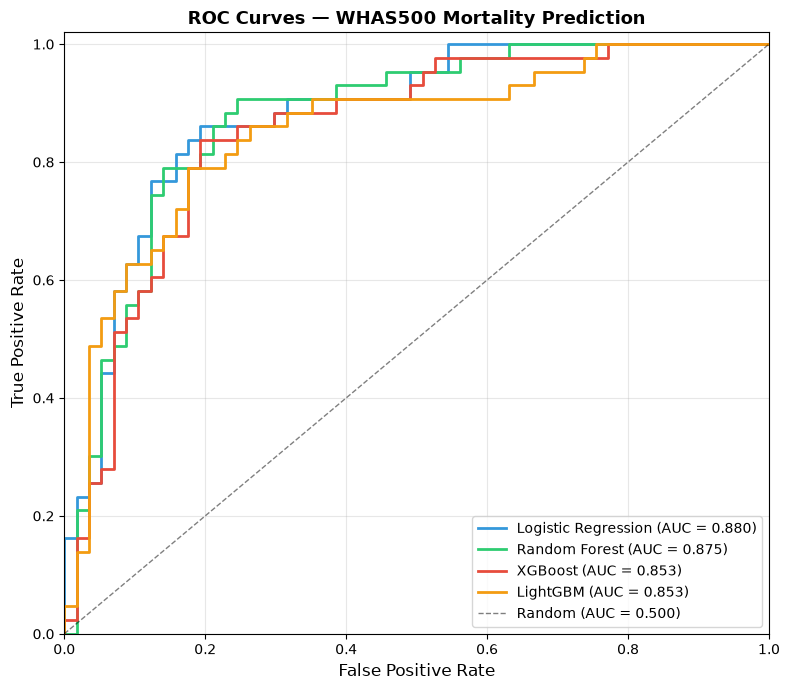

In [6]:
from src.visualisation.plots import plot_roc_curves

fig = plot_roc_curves(models_w, X_test_w, y_test_w,
                       title='ROC Curves — WHAS500 Mortality Prediction')
plt.show()